# Datathon 2026 - Part 2 EDA

This notebook is organized around one business thesis: the main bottlenecks are **margin leakage during Urban Blowout promotions** and **chronic stockout exposure in revenue-heavy categories**, not traffic generation or shipping SLA.

**Storyline**
1. Revenue reconstruction is clean, but the worst gross-margin days all cluster around Urban Blowout promotions.
2. A COVID-era structural-break lens provides context for the 2020-2021 shift without introducing external data or causal overclaim.
3. Promotions reach 38.66% of item lines, yet promo orders carry 20.5% lower AOV than non-promo orders.
4. Streetwear dominates revenue, while GenZ and Outdoor are more margin-efficient on a rate basis.
5. Repeat purchasing drops fast after the first month, so the first 30-60 days matter most for lifecycle activation.
6. Inventory is the bigger operational constraint: stockout runs at 67.34% overall, while shipping remains tightly bounded.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
from pathlib import Path

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
from IPython.display import display

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('.')

def compact_number(x, pos=None):
    x = float(x)
    abs_x = abs(x)
    if abs_x >= 1_000_000_000:
        return f'{x / 1_000_000_000:.1f}B'
    if abs_x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if abs_x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:,.0f}'


In [2]:
# Load datasets with basic typing
products = pd.read_csv(DATA_DIR / 'products.csv')
customers = pd.read_csv(DATA_DIR / 'customers.csv', parse_dates=['signup_date'])
promotions = pd.read_csv(DATA_DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
geography = pd.read_csv(DATA_DIR / 'geography.csv')
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', dtype={'promo_id_2': 'string'})
payments = pd.read_csv(DATA_DIR / 'payments.csv')
shipments = pd.read_csv(DATA_DIR / 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(DATA_DIR / 'returns.csv', parse_dates=['return_date'])
reviews = pd.read_csv(DATA_DIR / 'reviews.csv', parse_dates=['review_date'])
sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])

sales.rename(columns={'Date': 'date'}, inplace=True)

## 1) Data quality foundation
Before drawing business conclusions, we validate row counts, missingness, and foreign-key coverage so the later joins can be trusted.


In [3]:
def profile_df(name, df):
    return pd.Series({
        'rows': len(df),
        'cols': df.shape[1],
        'missing_cells': df.isna().sum().sum(),
        'missing_pct': df.isna().mean().mean()
    }, name=name)

profiles = pd.concat([
    profile_df('products', products),
    profile_df('customers', customers),
    profile_df('promotions', promotions),
    profile_df('geography', geography),
    profile_df('orders', orders),
    profile_df('order_items', order_items),
    profile_df('payments', payments),
    profile_df('shipments', shipments),
    profile_df('returns', returns),
    profile_df('reviews', reviews),
    profile_df('sales', sales),
    profile_df('inventory', inventory),
    profile_df('web_traffic', web_traffic)
], axis=1).T
profiles.sort_values('rows', ascending=False)

,rows,cols,missing_cells,missing_pct
order_items,714669.0,7.0,1152816.0,0.23044
orders,646945.0,8.0,0.0,0.00000
payments,646945.0,4.0,0.0,0.00000
shipments,566067.0,4.0,0.0,0.00000
customers,121930.0,7.0,0.0,0.00000
reviews,113551.0,7.0,0.0,0.00000
inventory,60247.0,17.0,0.0,0.00000
geography,39948.0,4.0,0.0,0.00000
returns,39939.0,7.0,0.0,0.00000
sales,3833.0,3.0,0.0,0.00000


In [4]:
# Top missing columns by dataset
def missing_report(df, top=10):
    miss = df.isna().mean().sort_values(ascending=False)
    return miss.head(top)

missing_summary = {
    'customers': missing_report(customers, 6),
    'orders': missing_report(orders, 6),
    'order_items': missing_report(order_items, 6),
    'shipments': missing_report(shipments, 6),
    'returns': missing_report(returns, 6),
    'reviews': missing_report(reviews, 6)
}
missing_summary

{'customers': customer_id    0.0
 zip            0.0
 city           0.0
 signup_date    0.0
 gender         0.0
 age_group      0.0
 dtype: float64,
 'orders': order_id          0.0
 order_date        0.0
 customer_id       0.0
 zip               0.0
 order_status      0.0
 payment_method    0.0
 dtype: float64,
 'order_items': promo_id_2    0.999712
 promo_id      0.613365
 order_id      0.000000
 product_id    0.000000
 quantity      0.000000
 unit_price    0.000000
 dtype: float64,
 'shipments': order_id         0.0
 ship_date        0.0
 delivery_date    0.0
 shipping_fee     0.0
 dtype: float64,
 'returns': return_id          0.0
 order_id           0.0
 product_id         0.0
 return_date        0.0
 return_reason      0.0
 return_quantity    0.0
 dtype: float64,
 'reviews': review_id      0.0
 order_id       0.0
 product_id     0.0
 customer_id    0.0
 review_date    0.0
 rating         0.0
 dtype: float64}

In [5]:
# FK coverage for key joins
def fk_coverage(child, child_col, parent, parent_col, label):
    s = child[child_col].dropna()
    matched = s.isin(parent[parent_col].dropna()).mean() if len(s) else np.nan
    return {
        'check': label,
        'child_rows_checked': len(s),
        'coverage_pct': 100 * matched if pd.notna(matched) else np.nan,
    }

fk_rows = [
    fk_coverage(orders, 'customer_id', customers, 'customer_id', 'orders.customer_id -> customers.customer_id'),
    fk_coverage(orders, 'zip', geography, 'zip', 'orders.zip -> geography.zip'),
    fk_coverage(order_items, 'order_id', orders, 'order_id', 'order_items.order_id -> orders.order_id'),
    fk_coverage(order_items, 'product_id', products, 'product_id', 'order_items.product_id -> products.product_id'),
    fk_coverage(payments, 'order_id', orders, 'order_id', 'payments.order_id -> orders.order_id'),
    fk_coverage(shipments, 'order_id', orders, 'order_id', 'shipments.order_id -> orders.order_id'),
    fk_coverage(returns, 'order_id', orders, 'order_id', 'returns.order_id -> orders.order_id'),
    fk_coverage(reviews, 'order_id', orders, 'order_id', 'reviews.order_id -> orders.order_id'),
    fk_coverage(returns, 'product_id', products, 'product_id', 'returns.product_id -> products.product_id'),
    fk_coverage(reviews, 'product_id', products, 'product_id', 'reviews.product_id -> products.product_id'),
    fk_coverage(reviews, 'customer_id', customers, 'customer_id', 'reviews.customer_id -> customers.customer_id'),
    fk_coverage(inventory, 'product_id', products, 'product_id', 'inventory.product_id -> products.product_id'),
    fk_coverage(order_items, 'promo_id', promotions, 'promo_id', 'order_items.promo_id -> promotions.promo_id'),
    fk_coverage(order_items, 'promo_id_2', promotions, 'promo_id', 'order_items.promo_id_2 -> promotions.promo_id'),
]

fk_df = pd.DataFrame(fk_rows).sort_values('coverage_pct', ascending=False)
fk_df

,check,child_rows_checked,coverage_pct
0,orders.customer_id -> customers.customer_id,646945,100.0
1,orders.zip -> geography.zip,646945,100.0
2,order_items.order_id -> orders.order_id,714669,100.0
3,order_items.product_id -> products.product_id,714669,100.0
4,payments.order_id -> orders.order_id,646945,100.0
5,shipments.order_id -> orders.order_id,566067,100.0
6,returns.order_id -> orders.order_id,39939,100.0
7,reviews.order_id -> orders.order_id,113551,100.0
8,returns.product_id -> products.product_id,39939,100.0
9,reviews.product_id -> products.product_id,113551,100.0


**Notes**
- `promo_id` and `promo_id_2` are null when no promotion is applied, so null here is expected rather than a data-quality failure.
- The main dimensional joins have 100% foreign-key coverage, which reduces the risk of double counting or orphan records in the later analyses.
- `shipments` only exist for shipped, delivered, or returned orders, consistent with the problem statement.
- This quality check is supporting evidence only; the main business story starts from margin, promotions, retention, and inventory.


## 2) Margin leakage is concentrated in Urban Blowout campaigns
Long-run growth is visible, but the key question is whether that growth is profitable. The next two views isolate where margin breaks.


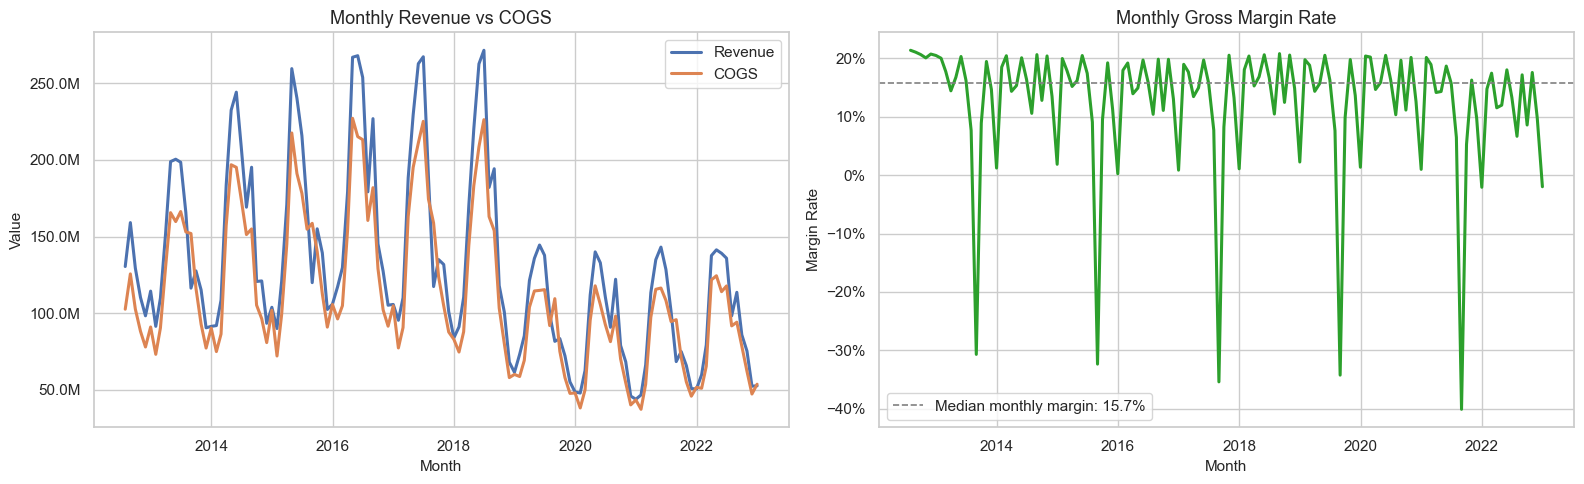

In [6]:
sales = sales.sort_values('date')
sales['gross_margin'] = sales['Revenue'] - sales['COGS']
sales['margin_rate'] = sales['gross_margin'] / sales['Revenue']

monthly_sales = sales.set_index('date').resample('M').sum(numeric_only=True)
monthly_sales['margin_rate'] = monthly_sales['gross_margin'] / monthly_sales['Revenue']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_sales.index, monthly_sales['Revenue'], label='Revenue', linewidth=2.2)
axes[0].plot(monthly_sales.index, monthly_sales['COGS'], label='COGS', linewidth=2.2)
axes[0].set_title('Monthly Revenue vs COGS')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Value')
axes[0].yaxis.set_major_formatter(FuncFormatter(compact_number))
axes[0].legend()

axes[1].plot(monthly_sales.index, monthly_sales['margin_rate'], color='tab:green', linewidth=2.2)
axes[1].axhline(monthly_sales['margin_rate'].median(), color='gray', linestyle='--', linewidth=1.2,
                label=f"Median monthly margin: {monthly_sales['margin_rate'].median():.1%}")
axes[1].set_title('Monthly Gross Margin Rate')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Margin Rate')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

plt.tight_layout()
plt.show()


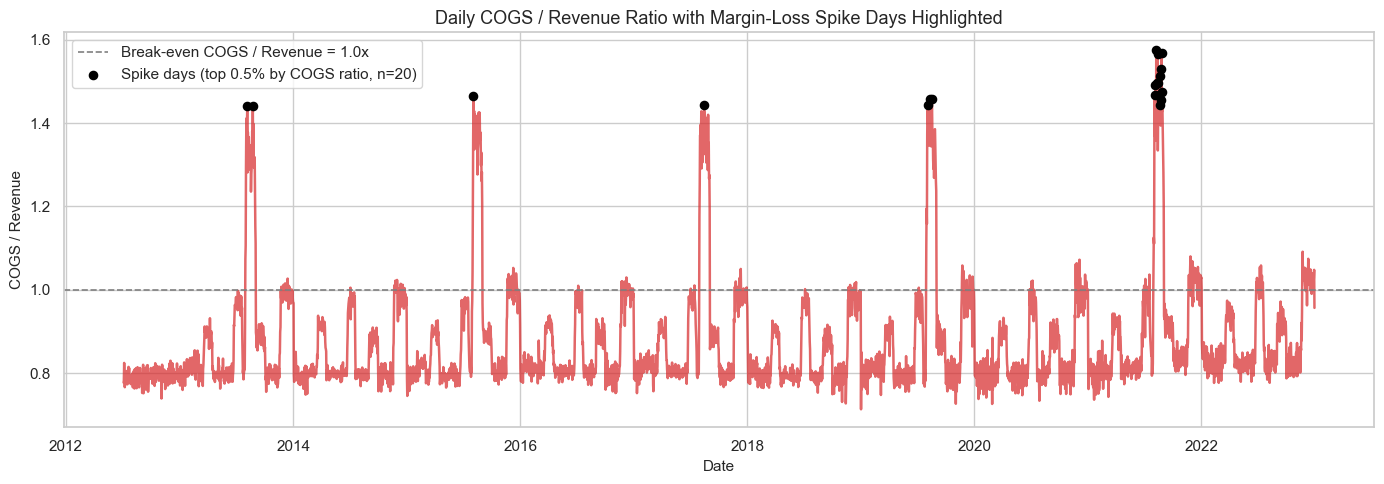

,value
max_abs_Revenue_diff,0.000000
max_abs_COGS_diff,0.004999
overall_margin_rate,0.137977
median_daily_margin_rate,0.178300


,metric,value
0,Spike days in top 0.5% COGS/Revenue,20
1,Share aligned with Urban Blowout,100.0%


,date,promo_names,cogs_ratio,margin_pct,promo_rev_share,promo_qty_share
9,2021-08-09,Urban Blowout 2021,1.57x,-57.5%,88.3%,79.3%
18,2021-08-26,Urban Blowout 2021,1.57x,-56.9%,82.8%,73.4%
11,2021-08-13,Urban Blowout 2021,1.57x,-56.6%,86.7%,82.6%
16,2021-08-24,Urban Blowout 2021,1.53x,-52.9%,79.3%,71.1%
14,2021-08-20,Urban Blowout 2021,1.51x,-51.2%,78.9%,65.1%
10,2021-08-11,Urban Blowout 2021,1.50x,-49.7%,83.1%,69.3%
12,2021-08-16,Urban Blowout 2021,1.50x,-49.5%,81.4%,74.8%
8,2021-08-06,Urban Blowout 2021,1.49x,-49.2%,77.5%,65.1%
19,2021-08-28,Urban Blowout 2021,1.47x,-47.3%,75.1%,64.3%
13,2021-08-17,Urban Blowout 2021,1.47x,-46.7%,76.7%,67.2%


In [7]:
# Revenue/COGS reconstruction and margin spike check
item_fact = (
    order_items
    .merge(orders[['order_id', 'order_date']], on='order_id', how='left')
    .merge(products[['product_id', 'cogs']], on='product_id', how='left')
)
item_fact['item_revenue_calc'] = item_fact['quantity'] * item_fact['unit_price']
item_fact['calc_cogs'] = item_fact['quantity'] * item_fact['cogs']
item_fact['has_promo'] = item_fact['promo_id'].notna() | item_fact['promo_id_2'].notna()

daily_recon = (
    item_fact.groupby('order_date', as_index=False)
    .agg(
        Revenue_calc=('item_revenue_calc', 'sum'),
        COGS_calc=('calc_cogs', 'sum'),
        discount_total=('discount_amount', 'sum'),
        promo_revenue=('item_revenue_calc', lambda s: s[item_fact.loc[s.index, 'has_promo']].sum()),
        promo_qty=('quantity', lambda s: s[item_fact.loc[s.index, 'has_promo']].sum()),
        total_qty=('quantity', 'sum'),
    )
    .rename(columns={'order_date': 'date'})
)

payment_daily = (
    orders[['order_id', 'order_date']]
    .merge(payments[['order_id', 'payment_value']], on='order_id', how='left')
    .groupby('order_date', as_index=False)
    .agg(payment_value=('payment_value', 'sum'))
    .rename(columns={'order_date': 'date'})
)

compare_target = (
    sales.merge(daily_recon, on='date', how='left')
    .merge(payment_daily, on='date', how='left')
)
compare_target['Revenue_diff'] = compare_target['Revenue'] - compare_target['Revenue_calc']
compare_target['COGS_diff'] = compare_target['COGS'] - compare_target['COGS_calc']
compare_target['payment_vs_revenue_diff'] = compare_target['Revenue'] - compare_target['payment_value']
compare_target['cogs_ratio'] = compare_target['COGS'] / compare_target['Revenue']
compare_target['margin_pct'] = (compare_target['Revenue'] - compare_target['COGS']) / compare_target['Revenue']

recon_summary = pd.Series({
    'max_abs_Revenue_diff': compare_target['Revenue_diff'].abs().max(),
    'max_abs_COGS_diff': compare_target['COGS_diff'].abs().max(),
    'overall_margin_rate': (compare_target['Revenue'].sum() - compare_target['COGS'].sum()) / compare_target['Revenue'].sum(),
    'median_daily_margin_rate': compare_target['margin_pct'].median(),
}).round(6)

spike_threshold = compare_target['cogs_ratio'].quantile(0.995)
spike_days = compare_target[compare_target['cogs_ratio'] >= spike_threshold].copy()

def active_promos_for_date(d):
    active = promotions[(promotions['start_date'] <= d) & (promotions['end_date'] >= d)]
    return pd.Series({
        'active_promos': len(active),
        'promo_names': ', '.join(active['promo_name'].unique()[:3]),
    })

promo_active = spike_days['date'].apply(active_promos_for_date)
spike_days = pd.concat([spike_days[['date', 'Revenue', 'COGS', 'cogs_ratio', 'margin_pct']], promo_active], axis=1)

promo_mix_daily = (
    item_fact.groupby('order_date', as_index=False)
    .agg(
        total_revenue=('item_revenue_calc', 'sum'),
        promo_revenue=('item_revenue_calc', lambda s: s[item_fact.loc[s.index, 'has_promo']].sum()),
        total_qty=('quantity', 'sum'),
        promo_qty=('quantity', lambda s: s[item_fact.loc[s.index, 'has_promo']].sum()),
        promo_cogs=('calc_cogs', lambda s: s[item_fact.loc[s.index, 'has_promo']].sum()),
    )
    .rename(columns={'order_date': 'date'})
)
promo_mix_daily['promo_rev_share'] = promo_mix_daily['promo_revenue'] / promo_mix_daily['total_revenue']
promo_mix_daily['promo_qty_share'] = promo_mix_daily['promo_qty'] / promo_mix_daily['total_qty']
promo_mix_daily['promo_cogs_ratio'] = promo_mix_daily['promo_cogs'] / promo_mix_daily['promo_revenue']

spike_mix = spike_days.merge(promo_mix_daily, on='date', how='left')
urban_blowout_share = spike_mix['promo_names'].str.contains('Urban Blowout', na=False).mean()
urban_blowout_summary = pd.DataFrame({
    'metric': ['Spike days in top 0.5% COGS/Revenue', 'Share aligned with Urban Blowout'],
    'value': [len(spike_mix), f'{urban_blowout_share:.1%}']
})

spike_summary = (
    spike_mix[['date', 'promo_names', 'cogs_ratio', 'margin_pct', 'promo_rev_share', 'promo_qty_share']]
    .sort_values('cogs_ratio', ascending=False)
    .head(10)
    .assign(
        cogs_ratio=lambda df: df['cogs_ratio'].map(lambda x: f'{x:.2f}x'),
        margin_pct=lambda df: df['margin_pct'].map(lambda x: f'{x:.1%}'),
        promo_rev_share=lambda df: df['promo_rev_share'].map(lambda x: f'{x:.1%}'),
        promo_qty_share=lambda df: df['promo_qty_share'].map(lambda x: f'{x:.1%}')
    )
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(compare_target['date'], compare_target['cogs_ratio'], color='tab:red', alpha=0.7, linewidth=1.8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, label='Break-even COGS / Revenue = 1.0x')
ax.scatter(spike_days['date'], spike_days['cogs_ratio'], color='black', s=35, zorder=3,
           label=f'Spike days (top 0.5% by COGS ratio, n={len(spike_days)})')
ax.set_title('Daily COGS / Revenue Ratio with Margin-Loss Spike Days Highlighted')
ax.set_xlabel('Date')
ax.set_ylabel('COGS / Revenue')
ax.legend()
plt.tight_layout()
plt.show()

display(recon_summary.to_frame('value'))
display(urban_blowout_summary)
display(spike_summary)


**Insights**
- Revenue and COGS reconstruct almost perfectly from order items: the maximum absolute revenue gap is effectively zero and the maximum COGS gap is below `0.01`, so the downstream margin analysis is reliable.
- Among the top **0.5%** `COGS / Revenue` spike days, **100%** fall inside an **Urban Blowout** campaign window.
- On those spike days, `COGS / Revenue` reaches **1.44x-1.57x**, which implies gross margin of roughly **-44% to -57% before fulfillment or marketing cost**.
- Promo-heavy mix explains the distortion: spike days still carry **69%-88% promo revenue share**, so this is a campaign design problem rather than isolated order outliers.

**Business implication**
- Add a promo guardrail before launch: reject campaign rules when projected gross margin falls below a minimum threshold such as **10%-15%**, and hard-block any campaign with projected `COGS / Revenue >= 1.0x`.


## 2B) COVID-era structural shift (context only)
The dataset has no external pandemic indicator, so this split is used only as a structural-break lens. It helps test whether 2020-2021 looks materially different from the pre-2020 pattern and the 2022 recovery period.


/var/folders/wq/6g3w3nkd1blcc86q405jp8y00000gn/T/ipykernel_90927/4196023925.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  covid_sales.groupby('period').agg(
/var/folders/wq/6g3w3nkd1blcc86q405jp8y00000gn/T/ipykernel_90927/4196023925.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .join(covid_orders.groupby('period').agg(avg_daily_orders=('orders', 'mean')))
/var/folders/wq/6g3w3nkd1blcc86q405jp8y00000gn/T/ipykernel_90927/4196023925.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

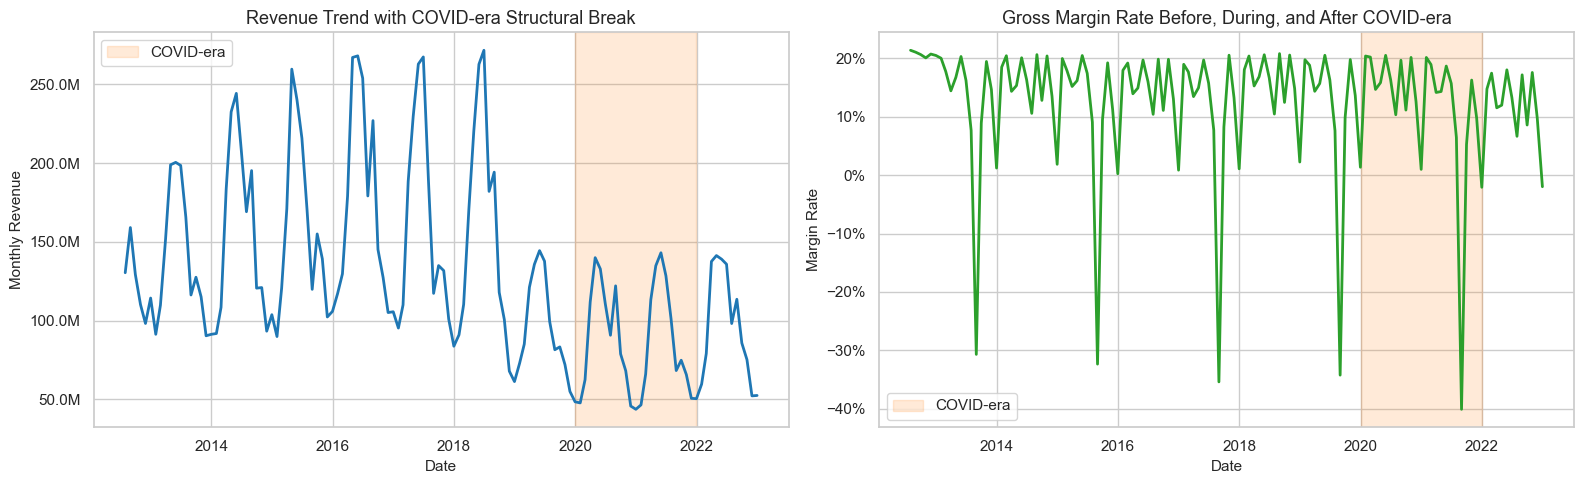

,avg_daily_revenue,median_daily_revenue,avg_margin_rate,avg_daily_orders,avg_sessions,avg_orders_per_session,avg_promo_revenue_share,avg_ship_lag,avg_delivery_days,avg_stockout_rate
period,,,,,,,,,,
Pre-COVID,4.809344e+06,4133214.74,0.1285,197.8571,23007.0704,0.0091,0.3595,1.4994,4.4977,0.6747
COVID-era,2.869428e+06,2502006.18,0.1160,94.9466,29525.0438,0.0032,0.3780,1.4971,4.5054,0.6714
2022 recovery,3.204791e+06,2945501.79,0.1209,98.6411,30311.3918,0.0033,0.3413,1.4852,4.5103,0.6670


In [8]:
def assign_structural_period(series):
    return pd.cut(
        series,
        bins=pd.to_datetime(['2012-07-04', '2019-12-31', '2021-12-31', '2022-12-31']),
        labels=['Pre-COVID', 'COVID-era', '2022 recovery'],
        include_lowest=True
    )

covid_sales = sales[['date', 'Revenue', 'COGS']].copy()
covid_sales['margin_rate'] = (covid_sales['Revenue'] - covid_sales['COGS']) / covid_sales['Revenue']
covid_sales['cogs_ratio'] = covid_sales['COGS'] / covid_sales['Revenue']
covid_sales['period'] = assign_structural_period(covid_sales['date'])

covid_orders = (
    orders.groupby('order_date', as_index=False)
    .agg(orders=('order_id', 'nunique'))
    .rename(columns={'order_date': 'date'})
)
covid_orders['period'] = assign_structural_period(covid_orders['date'])

covid_traffic = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
)
covid_traffic['period'] = assign_structural_period(covid_traffic['date'])

covid_demand = covid_traffic.merge(covid_orders, on=['date', 'period'], how='left').fillna({'orders': 0})
covid_demand['orders_per_session'] = covid_demand['orders'] / covid_demand['sessions'].replace(0, np.nan)

covid_items = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left').copy()
covid_items['item_revenue'] = covid_items['quantity'] * covid_items['unit_price']
covid_items['has_promo'] = covid_items['promo_id'].notna() | covid_items['promo_id_2'].notna()
covid_items['promo_revenue'] = np.where(covid_items['has_promo'], covid_items['item_revenue'], 0)

covid_promo = covid_items.groupby('order_date', as_index=False).agg(
    promo_line_rate=('has_promo', 'mean'),
    promo_revenue=('promo_revenue', 'sum'),
    total_revenue=('item_revenue', 'sum')
).rename(columns={'order_date': 'date'})
covid_promo['promo_revenue_share'] = covid_promo['promo_revenue'] / covid_promo['total_revenue']
covid_promo['period'] = assign_structural_period(covid_promo['date'])

covid_ship = shipments.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
covid_ship['ship_lag_days'] = (covid_ship['ship_date'] - covid_ship['order_date']).dt.days
covid_ship['delivery_days'] = (covid_ship['delivery_date'] - covid_ship['ship_date']).dt.days
covid_ship['period'] = assign_structural_period(covid_ship['order_date'])

covid_inventory = inventory.copy()
covid_inventory['period'] = assign_structural_period(covid_inventory['snapshot_date'])

covid_summary = (
    covid_sales.groupby('period').agg(
        avg_daily_revenue=('Revenue', 'mean'),
        median_daily_revenue=('Revenue', 'median'),
        avg_margin_rate=('margin_rate', 'mean')
    )
    .join(covid_orders.groupby('period').agg(avg_daily_orders=('orders', 'mean')))
    .join(covid_demand.groupby('period').agg(
        avg_sessions=('sessions', 'mean'),
        avg_orders_per_session=('orders_per_session', 'mean')
    ))
    .join(covid_promo.groupby('period').agg(avg_promo_revenue_share=('promo_revenue_share', 'mean')))
    .join(covid_ship.groupby('period').agg(
        avg_ship_lag=('ship_lag_days', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    ))
    .join(covid_inventory.groupby('period').agg(avg_stockout_rate=('stockout_flag', 'mean')))
    .round(4)
)

monthly_covid = covid_sales.set_index('date').resample('M').sum(numeric_only=True).reset_index()
monthly_covid['margin_rate'] = (monthly_covid['Revenue'] - monthly_covid['COGS']) / monthly_covid['Revenue']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_covid['date'], monthly_covid['Revenue'], color='tab:blue', linewidth=2.0)
axes[0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.16, color='tab:orange', label='COVID-era')
axes[0].set_title('Revenue Trend with COVID-era Structural Break')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Monthly Revenue')
axes[0].yaxis.set_major_formatter(FuncFormatter(compact_number))
axes[0].legend()

axes[1].plot(monthly_covid['date'], monthly_covid['margin_rate'], color='tab:green', linewidth=2.0)
axes[1].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.16, color='tab:orange', label='COVID-era')
axes[1].set_title('Gross Margin Rate Before, During, and After COVID-era')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Margin Rate')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

plt.tight_layout()
plt.show()

display(covid_summary)


**Insights**
- This split is **contextual, not causal**: the dataset contains no lockdown, infection, or policy variables, so the 2020-2021 label is used only to test for a structural break consistent with COVID-era e-commerce conditions.
- The break is visible. Average daily sessions rise from **23.0k** pre-COVID to **29.5k** in 2020-2021, yet average daily orders fall from **197.9** to **95.0** and the coarse conversion proxy `orders / session` drops from **0.91%** to **0.32%**.
- Revenue and profitability also soften during the same period: average daily revenue declines from **4.81M** to **2.87M**, while average gross margin rate slips from **12.85%** to **11.60%**.
- Promo intensity ticks up at the same time: average promo revenue share moves from **35.95%** pre-COVID to **37.80%** in the COVID-era split, while shipping remains broadly stable at roughly **1.5** ship-lag days and **4.5** delivery days.
- Stockout stays high across all periods at roughly **67%**, which suggests the inventory problem is structural rather than a one-off COVID shock.

**Business implication**
- The COVID-era split supports a structural-break view of the business: planning should not extrapolate traffic alone. Growth forecasts need to be paired with conversion quality, promo guardrails, and inventory capacity assumptions.


## 3) Basket quality matters more than raw order growth
Order demand is healthy, but the basket distribution is uneven. This matters because promo policy and upsell tactics should target the high-value tail without over-discounting the core basket.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


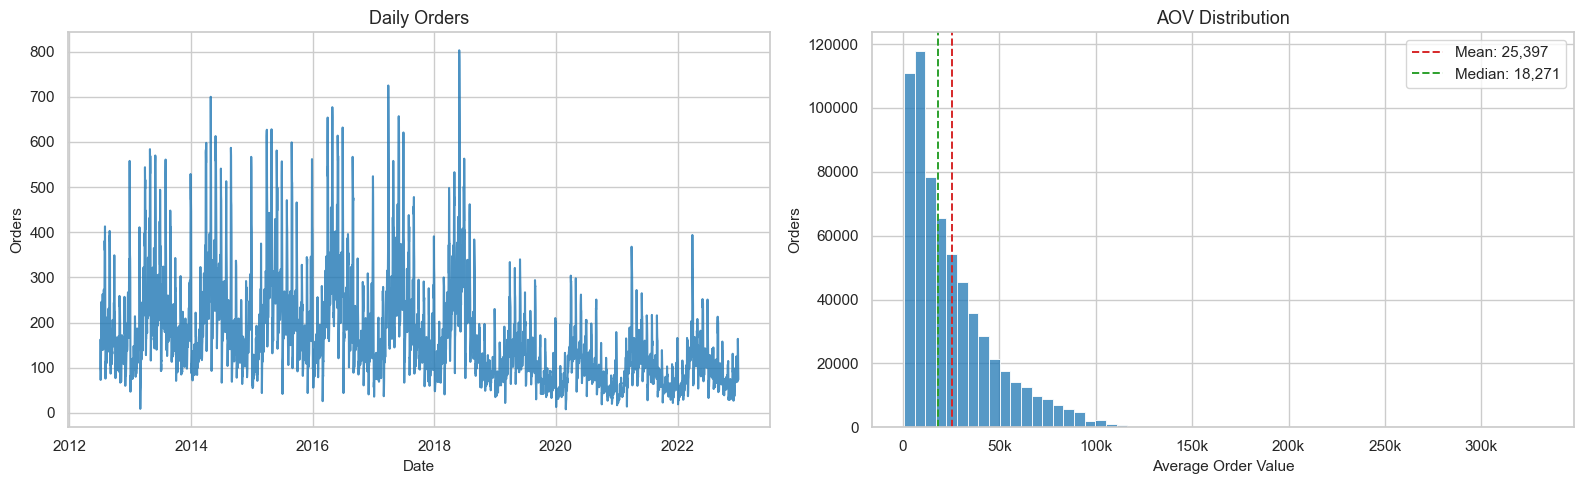

,aov
count,646945.00000
mean,25397.02229
std,23017.93393
min,442.89000
50%,18270.79000
75%,35339.20000
90%,57904.49200
95%,74090.14200
99%,99976.67160
max,331570.40000


In [9]:
# Order item revenue (unit_price already reflects discount)
order_items['item_revenue'] = order_items['quantity'] * order_items['unit_price']
order_items['item_discount'] = order_items['discount_amount'].fillna(0)

order_level = order_items.groupby('order_id', as_index=False).agg(
    items=('order_id', 'size'),
    units=('quantity', 'sum'),
    revenue=('item_revenue', 'sum'),
    discount=('item_discount', 'sum')
)

orders_enriched = orders.merge(order_level, on='order_id', how='left')
orders_enriched = orders_enriched.merge(payments, on='order_id', how='left', suffixes=('', '_payment'))

daily_orders = orders_enriched.groupby('order_date', as_index=False).agg(
    orders=('order_id', 'nunique'),
    revenue=('revenue', 'sum')
)

orders_enriched['aov'] = orders_enriched['revenue']
aov_summary = orders_enriched['aov'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(daily_orders['order_date'], daily_orders['orders'], color='tab:blue', alpha=0.8)
axes[0].set_title('Daily Orders')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Orders')
axes[0].yaxis.set_major_formatter(FuncFormatter(compact_number))

sns.histplot(orders_enriched['aov'].dropna(), bins=60, ax=axes[1], color='tab:blue')
axes[1].axvline(aov_summary['mean'], color='tab:red', linestyle='--', linewidth=1.4,
                label=f"Mean: {aov_summary['mean']:,.0f}")
axes[1].axvline(aov_summary['50%'], color='tab:green', linestyle='--', linewidth=1.4,
                label=f"Median: {aov_summary['50%']:,.0f}")
axes[1].set_title('AOV Distribution')
axes[1].set_xlabel('Average Order Value')
axes[1].set_ylabel('Orders')
axes[1].xaxis.set_major_formatter(FuncFormatter(compact_number))
axes[1].legend()

plt.tight_layout()
plt.show()

display(aov_summary.to_frame('aov'))


**Insights**
- Mean AOV is **25.4k**, which is **39.0% higher** than the median **18.3k**. Revenue is therefore being lifted by a relatively small high-value order tail rather than by a uniformly large basket base.
- The 75th percentile is already **35.3k**, while the maximum reaches **331.6k**, so there is room to target premium baskets with bundling or category-specific upsell.
- Daily order volume shows campaign-driven spikes, but the shape of the AOV distribution suggests that basket quality matters as much as raw order count.

**Business implication**
- Treat AOV as a quality metric, not just an output metric: push bundles, minimum-basket thresholds, and cross-sell prompts to protect the upper tail instead of using blanket discounts.


## 4) Retention drops quickly after the first purchase
The retention question is not whether customers ever come back, but how quickly the repurchase curve stabilizes after month 1. A customer is counted as retained only if they place another order in that later month.


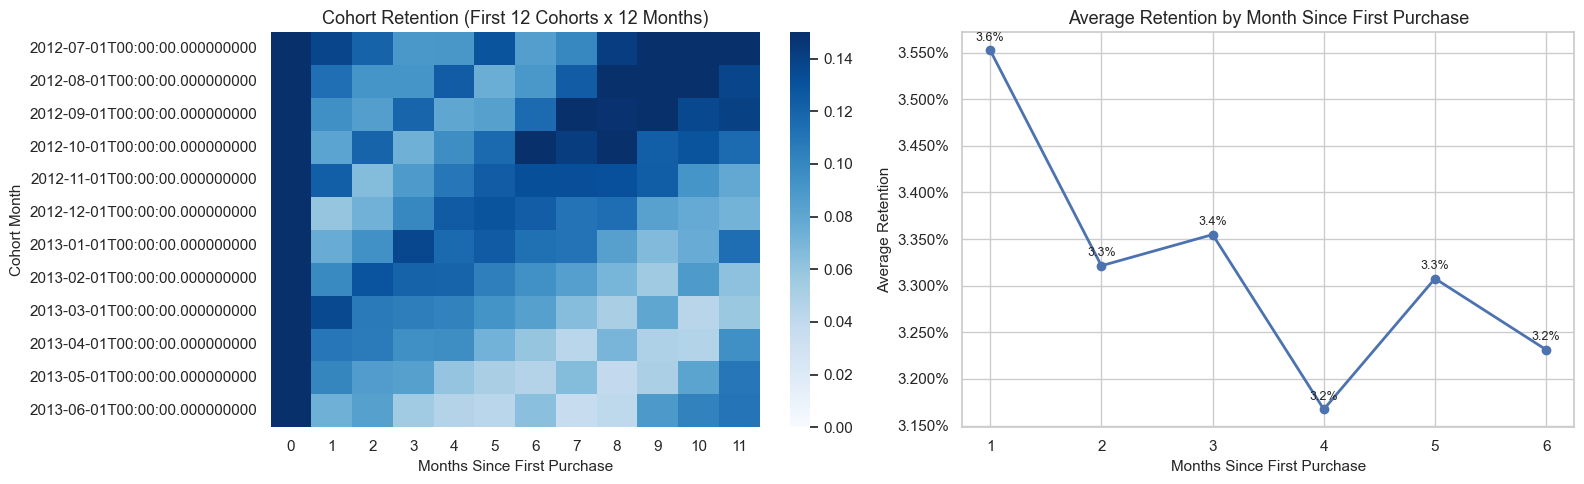

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2012-07-01,1.0,0.137825,0.120623,0.090109,0.090723,0.129429
2012-08-01,1.0,0.113446,0.091847,0.091652,0.124538,0.075112
2012-09-01,1.0,0.094725,0.085612,0.119028,0.080365,0.084507
2012-10-01,1.0,0.082161,0.119817,0.073412,0.095854,0.117155
2012-11-01,1.0,0.122592,0.066112,0.088441,0.109019,0.124781


,avg_retention
cohort_index,
1,0.035525
2,0.033214
3,0.033549
4,0.031675
5,0.033077
6,0.032313


In [10]:
orders_enriched['order_month'] = orders_enriched['order_date'].dt.to_period('M').dt.to_timestamp()
first_order = orders_enriched.groupby('customer_id')['order_month'].min().rename('cohort_month')
cohort = orders_enriched.join(first_order, on='customer_id')
cohort['cohort_index'] = (
    (cohort['order_month'].dt.year - cohort['cohort_month'].dt.year) * 12
    + (cohort['order_month'].dt.month - cohort['cohort_month'].dt.month)
)

cohort_counts = cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().unstack()
cohort_sizes = cohort_counts[0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

avg_retention = retention.iloc[:, 1:7].mean(skipna=True).rename('avg_retention')
avg_retention_df = avg_retention.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(retention.iloc[:12, :12], annot=False, cmap='Blues', mask=retention.iloc[:12, :12].isna(),
            vmin=0, vmax=0.15, ax=axes[0])
axes[0].set_title('Cohort Retention (First 12 Cohorts x 12 Months)')
axes[0].set_xlabel('Months Since First Purchase')
axes[0].set_ylabel('Cohort Month')

axes[1].plot(avg_retention_df['cohort_index'], avg_retention_df['avg_retention'], marker='o', linewidth=2.0)
for _, row in avg_retention_df.iterrows():
    axes[1].annotate(f"{row['avg_retention']:.1%}",
                     (row['cohort_index'], row['avg_retention']),
                     textcoords='offset points', xytext=(0, 7), ha='center', fontsize=9)
axes[1].set_title('Average Retention by Month Since First Purchase')
axes[1].set_xlabel('Months Since First Purchase')
axes[1].set_ylabel('Average Retention')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xticks(avg_retention_df['cohort_index'])

plt.tight_layout()
plt.show()

display(retention.iloc[:5, :6])
display(avg_retention.to_frame())


**Insights**
- Average month-1 retention is only **3.55%**, then it settles around **3.35% by month 3** and **3.23% by month 6**. The biggest drop happens immediately after the first purchase.
- This is a repeat-purchase cohort view, not web-session retention: a customer counts as retained only if they place another order in a later month.
- If month-1 retention stays near **3.55%**, medium-term growth will depend more on acquisition efficiency and basket expansion than on repeat-purchase compounding.

**Business implication**
- Trigger post-purchase journeys in the first two months: reorder reminders, complementary bundles, and category-specific vouchers should be tested before customers fall into the low-retention steady state.


## 5) Revenue is concentrated, but margin efficiency sits elsewhere
The category mix shows a classic trade-off: the largest revenue pool is not the cleanest source of margin.


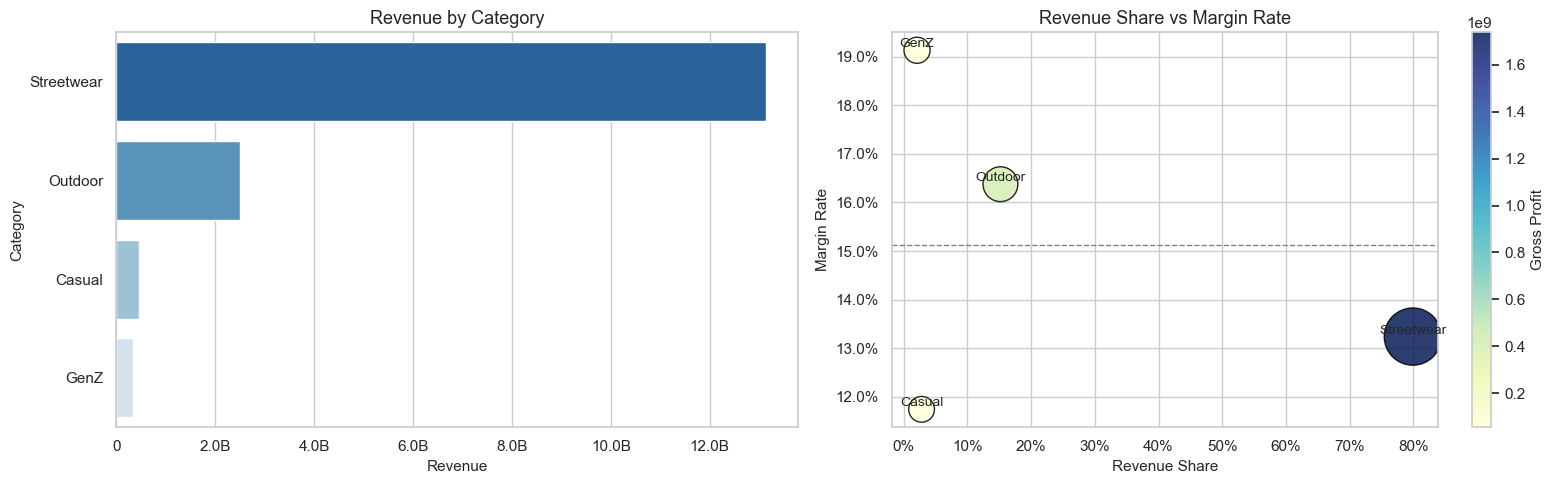

,category,revenue,gross_profit,units,margin_rate,revenue_share
3,Streetwear,1.313135e+10,1.738677e+09,1768826,0.132407,0.799207
2,Outdoor,2.494883e+09,4.085200e+08,1170000,0.163743,0.151845
0,Casual,4.606484e+08,5.410395e+07,107469,0.117452,0.028036
1,GenZ,3.435991e+08,6.572530e+07,166848,0.191285,0.020912


In [11]:
items_with_products = order_items.merge(products, on='product_id', how='left')
items_with_products['gross_profit'] = items_with_products['item_revenue'] - (items_with_products['cogs'] * items_with_products['quantity'])
items_with_products['net_revenue'] = items_with_products['item_revenue']

mix = items_with_products.groupby('category', as_index=False).agg(
    revenue=('net_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    units=('quantity', 'sum')
)
mix['margin_rate'] = mix['gross_profit'] / mix['revenue']
mix['revenue_share'] = mix['revenue'] / mix['revenue'].sum()
mix = mix.sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=mix, x='revenue', y='category', ax=axes[0], palette='Blues_r')
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Category')
axes[0].xaxis.set_major_formatter(FuncFormatter(compact_number))

bubble_size = 300 + 1400 * (mix['gross_profit'] / mix['gross_profit'].max())
scatter = axes[1].scatter(mix['revenue_share'], mix['margin_rate'], s=bubble_size,
                          c=mix['gross_profit'], cmap='YlGnBu', alpha=0.85, edgecolor='black')
for _, row in mix.iterrows():
    axes[1].text(row['revenue_share'], row['margin_rate'], row['category'],
                 fontsize=10, ha='center', va='bottom')
axes[1].axhline(mix['margin_rate'].mean(), color='gray', linestyle='--', linewidth=1.0)
axes[1].set_title('Revenue Share vs Margin Rate')
axes[1].set_xlabel('Revenue Share')
axes[1].set_ylabel('Margin Rate')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.colorbar(scatter, ax=axes[1], label='Gross Profit')

plt.tight_layout()
plt.show()

display(mix)


**Insights**
- **Streetwear** contributes about **13.13B** in revenue and nearly **79.9%** of total category sales, so it is the commercial core of the business.
- That scale does not translate into best efficiency: Streetwear margin rate is only **13.24%**, below **Outdoor (16.37%)** and well below **GenZ (19.13%)**.
- **GenZ** is the most margin-efficient category, but it contributes just **2.1%** of revenue, so it is better viewed as a selective profit lever than a demand engine.

**Business implication**
- Protect Streetwear margin before chasing more volume, and use GenZ or Outdoor items as bundle or upsell anchors to raise basket-level margin without depending on deeper markdowns in the core category.


## 6) Promotions expand reach but dilute basket quality
Promotions are too material to judge only on top-line sales. We need to check whether they increase good revenue or just shift customers into lower-value baskets.


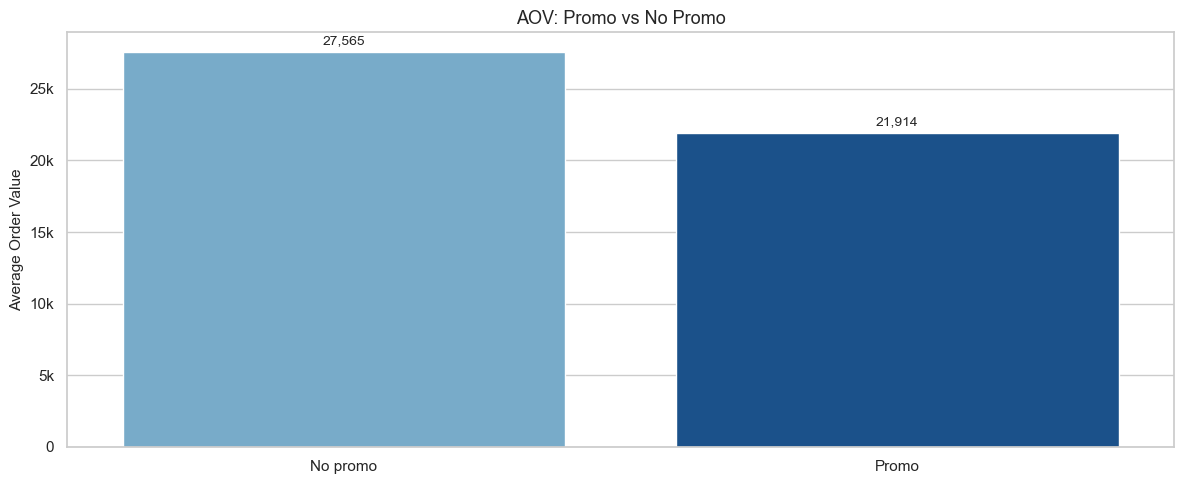

,metric,value
0,Promo line rate,38.66%
1,Promo order AOV,"21,914"
2,Non-promo order AOV,"27,565"
3,AOV gap vs non-promo,-20.5%


In [12]:
order_items['has_promo'] = order_items['promo_id'].notna() | order_items['promo_id_2'].notna()
promo_rate = order_items['has_promo'].mean()

promo_order_flag = order_items.groupby('order_id')['has_promo'].any().rename('has_promo')
orders_enriched = orders_enriched.join(promo_order_flag, on='order_id')

aov_by_promo = orders_enriched.groupby('has_promo', as_index=False)['aov'].mean()
aov_by_promo['segment'] = aov_by_promo['has_promo'].map({False: 'No promo', True: 'Promo'})
aov_promo = aov_by_promo.set_index('has_promo')['aov']
aov_gap_pct = (aov_promo.get(True, np.nan) / aov_promo.get(False, np.nan)) - 1

fig, ax = plt.subplots()
sns.barplot(data=aov_by_promo, x='segment', y='aov', ax=ax, palette=['#6baed6', '#08519c'])
for idx, row in aov_by_promo.iterrows():
    ax.text(idx, row['aov'] + 350, f"{row['aov']:,.0f}", ha='center', va='bottom', fontsize=10)
ax.set_title('AOV: Promo vs No Promo')
ax.set_xlabel('')
ax.set_ylabel('Average Order Value')
ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.tight_layout()
plt.show()

promo_summary = pd.DataFrame({
    'metric': ['Promo line rate', 'Promo order AOV', 'Non-promo order AOV', 'AOV gap vs non-promo'],
    'value': [f'{promo_rate:.2%}', f"{aov_promo.get(True, np.nan):,.0f}",
              f"{aov_promo.get(False, np.nan):,.0f}", f'{aov_gap_pct:.1%}']
})
display(promo_summary)


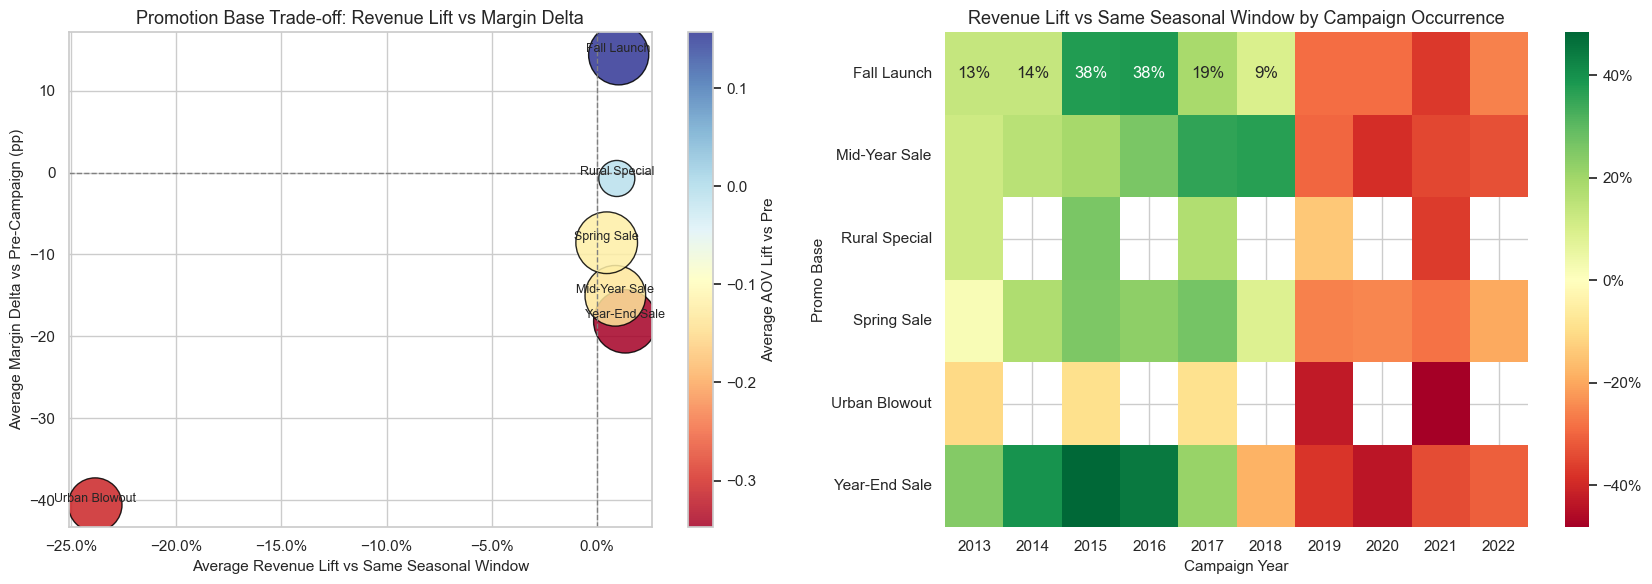

,promo_base,years_observed,avg_revenue_lift_vs_pre,avg_revenue_lift_vs_post,avg_revenue_lift_vs_seasonal,avg_margin_delta_vs_pre_pp,avg_margin_delta_vs_post_pp,avg_aov_lift_vs_pre,avg_aov_lift_vs_post,avg_base_promo_revenue_share,campaign_class
5,Year-End Sale,10,-0.2092,-0.0487,0.0136,-18.1705,-17.6366,-0.3476,-0.3588,0.9373,Volume but margin dilution
0,Fall Launch,10,-0.0668,0.2541,0.0104,14.3740,-10.6355,0.1568,-0.1047,0.8193,Likely demand shifting
2,Rural Special,5,0.3773,-0.3016,0.0095,-0.7265,2.6345,-0.0080,0.0103,0.1522,Likely demand shifting
1,Mid-Year Sale,10,-0.2806,0.1135,0.0088,-15.0542,5.4131,-0.1346,0.0234,0.8363,Volume but margin dilution
3,Spring Sale,10,0.5147,-0.0695,0.0047,-8.5738,-9.5341,-0.1228,-0.0941,0.8729,Likely demand shifting
4,Urban Blowout,5,-0.2633,0.0122,-0.2386,-40.5725,-45.4192,-0.3082,-0.3408,0.6109,Volume but margin dilution


,promo_base,promo_year,duration_days,during_avg_daily_revenue,revenue_lift_vs_pre,revenue_lift_vs_post,revenue_lift_vs_seasonal,during_margin_rate,margin_delta_vs_pre_pp,base_promo_revenue_share,during_aov,aov_lift_vs_pre,during_units_sold_per_day
0,Fall Launch,2013,34,4.430191e+06,0.0735,0.2298,0.1343,0.0758,33.8395,0.8650,22779.1850,0.3891,1028.1176
1,Fall Launch,2014,33,4.493279e+06,-0.2874,0.1644,0.1364,0.1324,-7.2558,0.7672,23575.6459,-0.0653,980.4242
2,Fall Launch,2015,33,5.319919e+06,0.2587,0.2144,0.3775,0.0750,37.3432,0.8594,21820.1977,0.3120,1247.6061
3,Fall Launch,2016,33,5.329297e+06,-0.2622,0.3038,0.3803,0.1131,-8.6135,0.7712,26004.2028,-0.0910,1025.4848
4,Fall Launch,2017,34,4.609882e+06,0.0663,0.0953,0.1864,0.0720,36.9484,0.8155,25279.4580,0.3804,956.9412
5,Fall Launch,2018,33,4.342427e+06,-0.3057,0.3906,0.0936,0.1271,-8.3053,0.8029,28784.8375,-0.0245,727.3333
6,Fall Launch,2019,33,2.938395e+06,0.1227,0.3151,-0.2880,0.0815,38.9950,0.8336,27569.8227,0.4124,538.9394
7,Fall Launch,2020,33,2.934879e+06,-0.2023,0.3672,-0.2889,0.1124,-8.9695,0.7826,31352.7278,-0.0498,446.0909
8,Fall Launch,2021,34,2.583218e+06,0.0308,0.2457,-0.3716,0.0386,38.7556,0.8511,30848.3327,0.3555,410.6471
9,Fall Launch,2022,32,2.964425e+06,-0.1622,0.2148,-0.2560,0.0845,-8.9974,0.8446,32602.4174,-0.0512,424.3750


In [13]:
# Promotion analysis at the campaign-base level
promo_catalog = promotions.copy()
promo_catalog['promo_base'] = promo_catalog['promo_name'].str.replace(r'\s+\d{4}$', '', regex=True)
promo_catalog['promo_year'] = promo_catalog['promo_name'].str.extract(r'(\d{4})$').astype(int)

promo_line_source = (
    order_items
    .reset_index()
    .rename(columns={'index': 'line_id'})
    .merge(orders[['order_id', 'order_date']], on='order_id', how='left')
)
promo_line_source['promo_ids'] = promo_line_source[['promo_id', 'promo_id_2']].apply(
    lambda row: [p for p in row if pd.notna(p)],
    axis=1
)
promo_line_source['promo_count'] = promo_line_source['promo_ids'].apply(len).replace(0, np.nan)
promo_line_source['allocated_revenue'] = promo_line_source['item_revenue'] / promo_line_source['promo_count']
promo_line_source['allocated_units'] = promo_line_source['quantity'] / promo_line_source['promo_count']

promo_long = promo_line_source[['line_id', 'order_date', 'promo_ids', 'allocated_revenue', 'allocated_units']].explode('promo_ids')
promo_long = promo_long.dropna(subset=['promo_ids']).rename(columns={'promo_ids': 'promo_id'})
promo_long = promo_long.merge(
    promo_catalog[['promo_id', 'promo_base', 'promo_year', 'promo_name', 'start_date', 'end_date']],
    on='promo_id',
    how='left'
)

base_daily = (
    promo_long.groupby(['order_date', 'promo_base', 'promo_year'], as_index=False)
    .agg(
        base_promo_revenue=('allocated_revenue', 'sum'),
        base_promo_units=('allocated_units', 'sum')
    )
    .rename(columns={'order_date': 'date'})
)

daily_business = (
    sales[['date', 'Revenue', 'COGS']]
    .merge(
        orders_enriched.groupby('order_date', as_index=False).agg(
            orders=('order_id', 'nunique'),
            aov=('aov', 'mean')
        ).rename(columns={'order_date': 'date'}),
        on='date',
        how='left'
    )
    .merge(
        order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
        .groupby('order_date', as_index=False)
        .agg(units_sold=('quantity', 'sum'))
        .rename(columns={'order_date': 'date'}),
        on='date',
        how='left'
    )
)
daily_business['gross_margin_rate'] = (daily_business['Revenue'] - daily_business['COGS']) / daily_business['Revenue']

all_years = sorted(promo_catalog['promo_year'].unique())
campaign_rows = []

def summarize_window(df):
    return {
        'avg_daily_revenue': df['Revenue'].mean(),
        'gross_margin_rate': df['gross_margin_rate'].mean(),
        'aov': df['aov'].mean(),
        'units_sold_per_day': df['units_sold'].mean(),
        'orders_per_day': df['orders'].mean(),
    }

for _, promo in promo_catalog.sort_values(['promo_base', 'promo_year']).iterrows():
    start = promo['start_date']
    end = promo['end_date']
    duration_days = (end - start).days + 1

    during = daily_business[(daily_business['date'] >= start) & (daily_business['date'] <= end)]
    pre = daily_business[(daily_business['date'] >= start - pd.Timedelta(days=duration_days)) & (daily_business['date'] < start)]
    post = daily_business[(daily_business['date'] > end) & (daily_business['date'] <= end + pd.Timedelta(days=duration_days))]

    seasonal_windows = []
    for other_year in all_years:
        if other_year == promo['promo_year']:
            continue
        offset = other_year - promo['promo_year']
        alt_start = start + pd.DateOffset(years=offset)
        alt_end = end + pd.DateOffset(years=offset)
        seasonal_windows.append(daily_business[(daily_business['date'] >= alt_start) & (daily_business['date'] <= alt_end)])
    seasonal = pd.concat(seasonal_windows, ignore_index=True) if seasonal_windows else pd.DataFrame(columns=daily_business.columns)

    during_summary = summarize_window(during)
    pre_summary = summarize_window(pre)
    post_summary = summarize_window(post)
    seasonal_summary = summarize_window(seasonal)

    base_window = base_daily[
        (base_daily['promo_base'] == promo['promo_base']) &
        (base_daily['promo_year'] == promo['promo_year']) &
        (base_daily['date'] >= start) &
        (base_daily['date'] <= end)
    ]
    base_promo_revenue_share = base_window['base_promo_revenue'].sum() / during['Revenue'].sum()
    base_promo_units_share = base_window['base_promo_units'].sum() / during['units_sold'].sum()

    campaign_rows.append({
        'promo_base': promo['promo_base'],
        'promo_year': promo['promo_year'],
        'duration_days': duration_days,
        'during_avg_daily_revenue': during_summary['avg_daily_revenue'],
        'pre_avg_daily_revenue': pre_summary['avg_daily_revenue'],
        'post_avg_daily_revenue': post_summary['avg_daily_revenue'],
        'seasonal_avg_daily_revenue': seasonal_summary['avg_daily_revenue'],
        'during_margin_rate': during_summary['gross_margin_rate'],
        'pre_margin_rate': pre_summary['gross_margin_rate'],
        'post_margin_rate': post_summary['gross_margin_rate'],
        'seasonal_margin_rate': seasonal_summary['gross_margin_rate'],
        'during_aov': during_summary['aov'],
        'pre_aov': pre_summary['aov'],
        'post_aov': post_summary['aov'],
        'seasonal_aov': seasonal_summary['aov'],
        'during_units_sold_per_day': during_summary['units_sold_per_day'],
        'pre_units_sold_per_day': pre_summary['units_sold_per_day'],
        'post_units_sold_per_day': post_summary['units_sold_per_day'],
        'base_promo_revenue_share': base_promo_revenue_share,
        'base_promo_units_share': base_promo_units_share,
    })

campaign_occurrence = pd.DataFrame(campaign_rows)

for comp in ['pre', 'post', 'seasonal']:
    campaign_occurrence[f'revenue_lift_vs_{comp}'] = (
        campaign_occurrence['during_avg_daily_revenue'] / campaign_occurrence[f'{comp}_avg_daily_revenue'] - 1
    )
    campaign_occurrence[f'margin_delta_vs_{comp}_pp'] = (
        (campaign_occurrence['during_margin_rate'] - campaign_occurrence[f'{comp}_margin_rate']) * 100
    )
    campaign_occurrence[f'aov_lift_vs_{comp}'] = (
        campaign_occurrence['during_aov'] / campaign_occurrence[f'{comp}_aov'] - 1
    )

promo_base_summary = (
    campaign_occurrence.groupby('promo_base', as_index=False)
    .agg(
        years_observed=('promo_year', 'count'),
        avg_revenue_lift_vs_pre=('revenue_lift_vs_pre', 'mean'),
        avg_revenue_lift_vs_post=('revenue_lift_vs_post', 'mean'),
        avg_revenue_lift_vs_seasonal=('revenue_lift_vs_seasonal', 'mean'),
        avg_margin_delta_vs_pre_pp=('margin_delta_vs_pre_pp', 'mean'),
        avg_margin_delta_vs_post_pp=('margin_delta_vs_post_pp', 'mean'),
        avg_aov_lift_vs_pre=('aov_lift_vs_pre', 'mean'),
        avg_aov_lift_vs_post=('aov_lift_vs_post', 'mean'),
        avg_base_promo_revenue_share=('base_promo_revenue_share', 'mean'),
    )
    .sort_values(['avg_revenue_lift_vs_seasonal', 'avg_margin_delta_vs_pre_pp'], ascending=[False, False])
)

def classify_campaign(row):
    if row['avg_revenue_lift_vs_seasonal'] > 0.03 and row['avg_margin_delta_vs_pre_pp'] > -2:
        return 'Healthy growth'
    if row['avg_margin_delta_vs_pre_pp'] <= -10 or row['avg_aov_lift_vs_pre'] <= -0.15:
        return 'Volume but margin dilution'
    if abs(row['avg_revenue_lift_vs_seasonal']) <= 0.03:
        return 'Likely demand shifting'
    return 'Weak / low-priority'

promo_base_summary['campaign_class'] = promo_base_summary.apply(classify_campaign, axis=1)

occurrence_view = campaign_occurrence[
    [
        'promo_base', 'promo_year', 'duration_days',
        'during_avg_daily_revenue', 'revenue_lift_vs_pre', 'revenue_lift_vs_post', 'revenue_lift_vs_seasonal',
        'during_margin_rate', 'margin_delta_vs_pre_pp',
        'base_promo_revenue_share', 'during_aov', 'aov_lift_vs_pre',
        'during_units_sold_per_day'
    ]
].sort_values(['promo_base', 'promo_year'])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

scatter = axes[0].scatter(
    promo_base_summary['avg_revenue_lift_vs_seasonal'],
    promo_base_summary['avg_margin_delta_vs_pre_pp'],
    s=400 + 1800 * promo_base_summary['avg_base_promo_revenue_share'],
    c=promo_base_summary['avg_aov_lift_vs_pre'],
    cmap='RdYlBu',
    edgecolor='black',
    alpha=0.85
)
for _, row in promo_base_summary.iterrows():
    axes[0].text(
        row['avg_revenue_lift_vs_seasonal'],
        row['avg_margin_delta_vs_pre_pp'],
        row['promo_base'],
        fontsize=9,
        ha='center',
        va='bottom'
    )
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1.0)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1.0)
axes[0].set_title('Promotion Base Trade-off: Revenue Lift vs Margin Delta')
axes[0].set_xlabel('Average Revenue Lift vs Same Seasonal Window')
axes[0].set_ylabel('Average Margin Delta vs Pre-Campaign (pp)')
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
plt.colorbar(scatter, ax=axes[0], label='Average AOV Lift vs Pre')

heatmap = occurrence_view.pivot(index='promo_base', columns='promo_year', values='revenue_lift_vs_seasonal')
sns.heatmap(heatmap, annot=True, fmt='.0%', cmap='RdYlGn', center=0, ax=axes[1], cbar_kws={'format': PercentFormatter(1)})
axes[1].set_title('Revenue Lift vs Same Seasonal Window by Campaign Occurrence')
axes[1].set_xlabel('Campaign Year')
axes[1].set_ylabel('Promo Base')

plt.tight_layout()
plt.show()

display(promo_base_summary.round(4))
display(occurrence_view.round(4))


**Insights**
- Promotions touch **38.66%** of item lines, so they are a structural part of the business rather than an occasional tactic.
- At the campaign-base level, **Urban Blowout** is the clearest value-destructive mechanic: average revenue is **26.3% below** the pre-campaign baseline and **23.9% below** the same seasonal window, while margin drops by roughly **40.6 percentage points** and AOV falls by **30.8%** versus pre-campaign levels.
- **Spring Sale** appears to pull demand forward rather than create strong incremental growth: revenue is **51.5% above** the immediately preceding window but only **0.5% above** the same seasonal window, while AOV is **12.3% lower** and margin is **8.6 percentage points** weaker than pre-campaign.
- **Mid-Year Sale** and **Year-End Sale** show a similar trade-off: both are broadly flat or negative against seasonal benchmarks, but they still compress margin and basket quality. **Year-End Sale** is especially weak, with average seasonal revenue lift around **-31.1%** and AOV roughly **34.8%** below pre-campaign levels.
- **Rural Special** is the least aggressive base: its promo revenue share is only about **15.5%** and margin stays comparatively stable, but seasonal revenue lift is still close to zero, so it looks more like a targeted conversion tool than a scalable growth engine.
- **Fall Launch** behaves more like a merchandising event than a true growth driver: seasonal revenue is roughly flat on average, but promo intensity remains extremely high at about **92.4%** of campaign-window revenue.

**Business implication**
- Promotion strategy should be set at the recurring campaign-base level, not by yearly promo IDs. In practice, **Urban Blowout** and **Year-End Sale** need the strictest guardrails or redesign, **Spring Sale** and **Mid-Year Sale** should be treated as demand-timing tools with tighter basket thresholds, and **Rural Special** should remain targeted rather than broadly scaled.


## Appendix A) Returns are present, but not the main separating signal
Returns still matter operationally, but the category spread is modest, so they are supporting evidence rather than the central business story.


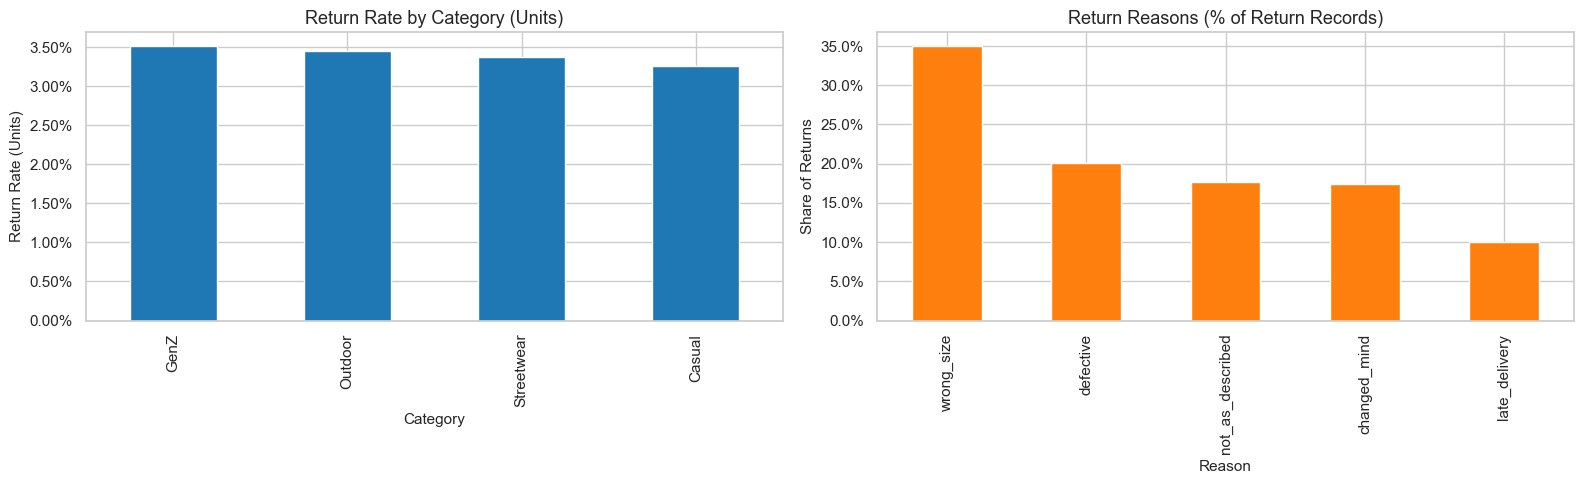

,share_pct
return_reason,
wrong_size,35.0
defective,20.1
not_as_described,17.6
changed_mind,17.4
late_delivery,10.0


,return_rate_units
category,
GenZ,0.035176
Outdoor,0.034544
Streetwear,0.033808
Casual,0.032558


,return_rate_lines
category,
GenZ,0.057214
Outdoor,0.056618
Streetwear,0.055393
Casual,0.053937


In [14]:
returns_items = returns.merge(products, on='product_id', how='left')
return_counts = returns_items.groupby('category')['return_id'].count().rename('returns')
return_units = returns_items.groupby('category')['return_quantity'].sum().rename('returned_units')

order_counts = items_with_products.groupby('category')['order_id'].count().rename('order_lines')
sold_units = items_with_products.groupby('category')['quantity'].sum().rename('sold_units')

return_rate_lines = (return_counts / order_counts).sort_values(ascending=False).dropna()
return_rate_units = (return_units / sold_units).sort_values(ascending=False).dropna()
reason_pct = returns['return_reason'].value_counts(normalize=True).mul(100).round(1).rename('share_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

return_rate_units.head(10).plot(kind='bar', ax=axes[0], color='tab:blue')
axes[0].set_title('Return Rate by Category (Units)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Return Rate (Units)')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

reason_pct.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_title('Return Reasons (% of Return Records)')
axes[1].set_xlabel('Reason')
axes[1].set_ylabel('Share of Returns')
axes[1].yaxis.set_major_formatter(PercentFormatter(100))

plt.tight_layout()
plt.show()

display(reason_pct.to_frame())
display(return_rate_units.head(10).to_frame('return_rate_units'))
display(return_rate_lines.head(10).to_frame('return_rate_lines'))


**Insights**
- Return-rate differences by category are relatively narrow when measured as `returned units / sold units`, so no single category stands out as a dominant structural failure.
- The return-reason mix is more actionable than the category league table: **wrong size accounts for 35.0%** of return records, followed by **defective (20.1%)** and **not as described (17.6%)**.

**Business implication**
- Prioritize root-cause fixes at the reason level first, especially sizing guidance and product expectation management, and keep category return rates as a monitoring metric rather than a headline decision variable.


## Appendix B) Fulfillment is stable, so it is not the main bottleneck
Shipping is worth checking because it can damage both ratings and repurchase, but the distribution here is unusually bounded.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


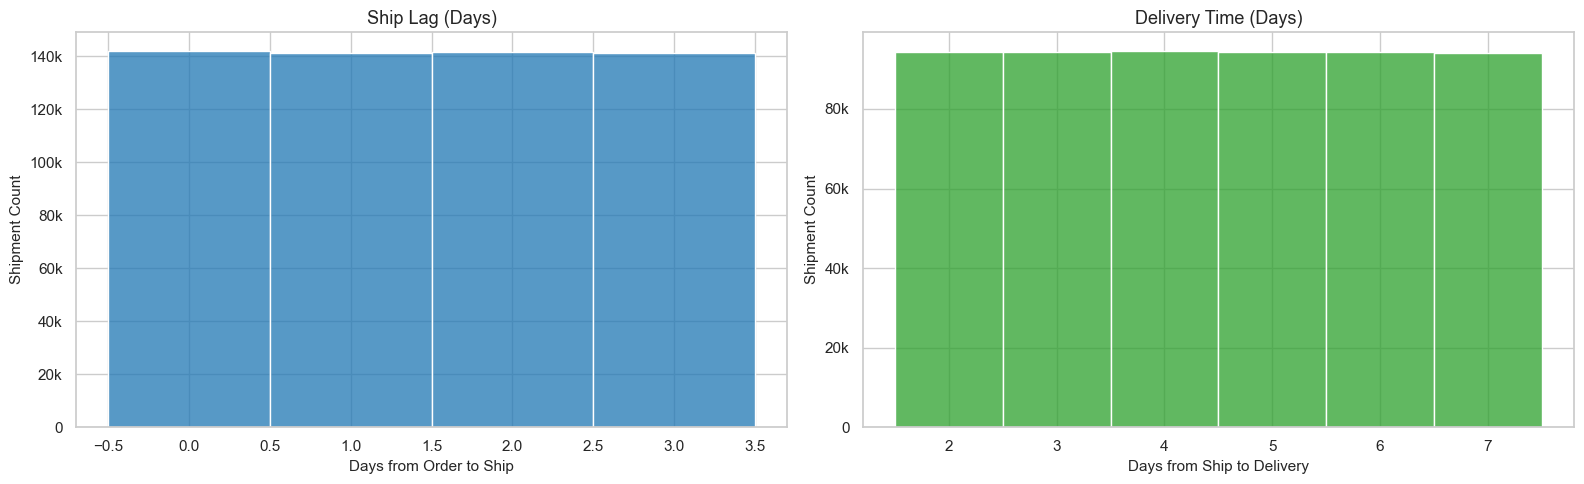

,ship_lag_days,delivery_days
count,566067.000000,566067.000000
mean,1.498384,4.499209
std,1.118417,1.707018
min,0.000000,2.000000
25%,0.000000,3.000000
50%,1.000000,4.000000
75%,2.000000,6.000000
max,3.000000,7.000000


In [15]:
ship = shipments.merge(orders[['order_id', 'order_date', 'zip']], on='order_id', how='left')
ship['ship_lag_days'] = (ship['ship_date'] - ship['order_date']).dt.days
ship['delivery_days'] = (ship['delivery_date'] - ship['ship_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(ship['ship_lag_days'].dropna(), bins=4, discrete=True, ax=axes[0], color='tab:blue')
axes[0].set_title('Ship Lag (Days)')
axes[0].set_xlabel('Days from Order to Ship')
axes[0].set_ylabel('Shipment Count')
axes[0].yaxis.set_major_formatter(FuncFormatter(compact_number))

sns.histplot(ship['delivery_days'].dropna(), bins=6, discrete=True, ax=axes[1], color='tab:green')
axes[1].set_title('Delivery Time (Days)')
axes[1].set_xlabel('Days from Ship to Delivery')
axes[1].set_ylabel('Shipment Count')
axes[1].yaxis.set_major_formatter(FuncFormatter(compact_number))

plt.tight_layout()
plt.show()

display(ship[['ship_lag_days', 'delivery_days']].describe())


**Insights**
- Ship lag averages **1.50 days** and is capped at **3 days**; delivery time averages **4.50 days** and is capped at **7 days**.
- The distributions are tight rather than long-tailed, which makes this a relatively controlled process compared with the promo and inventory problems above.

**Business implication**
- Fulfillment should be monitored, but it does not look like the primary constraint in this simulated business. Margin leakage and stockout deserve higher priority than shipping-SLA optimization.


## Appendix C) Ratings offer weak separation across categories
Review scores can be useful quality signals, but only if they meaningfully separate product groups.


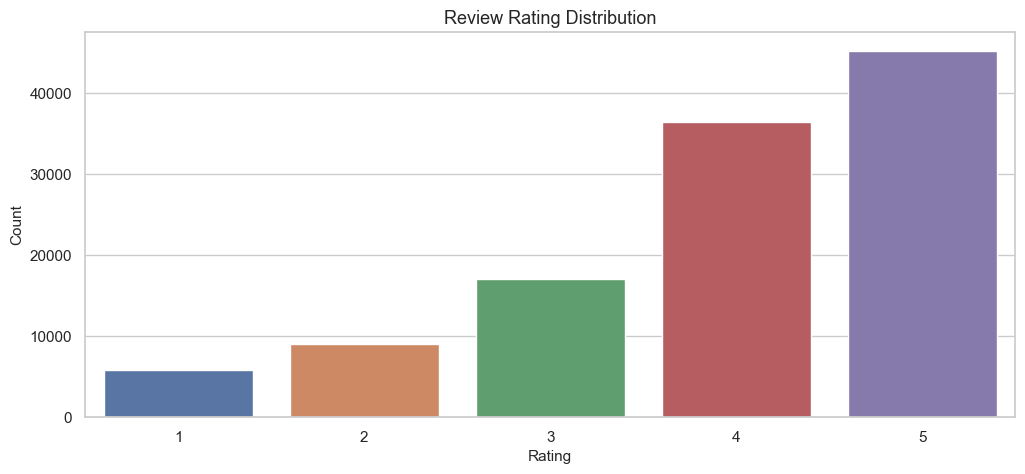

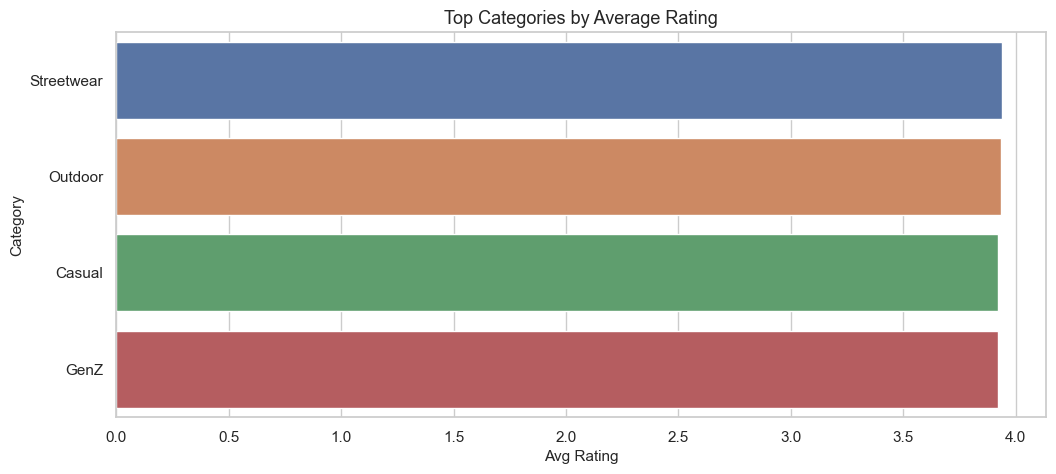

,category,rating
3,Streetwear,3.939398
2,Outdoor,3.933891
0,Casual,3.923219
1,GenZ,3.922825


In [16]:
fig, ax = plt.subplots()
sns.countplot(data=reviews, x='rating', ax=ax)
ax.set_title('Review Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
plt.show()

reviews_products = reviews.merge(products, on='product_id', how='left')
rating_by_category = reviews_products.groupby('category', as_index=False)['rating'].mean().sort_values('rating', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=rating_by_category.head(10), x='rating', y='category', ax=ax)
ax.set_title('Top Categories by Average Rating')
ax.set_xlabel('Avg Rating')
ax.set_ylabel('Category')
plt.show()

rating_by_category.head(10)

**Insights**
- Average rating is tightly clustered across categories: the spread from highest to lowest category average is only about **0.017 stars**.
- That means ratings are not a strong differentiator here. They are too compressed to explain the much larger business gaps seen in margin, promotion, and stockout.

**Business implication**
- Use ratings as a hygiene KPI, but rely more on return reasons, stockout exposure, and promo economics when deciding where to act first.


## Appendix D) Traffic provides context, but conversion is the harder problem
Web traffic matters for growth, but the stronger question is whether incremental sessions convert into orders efficiently.


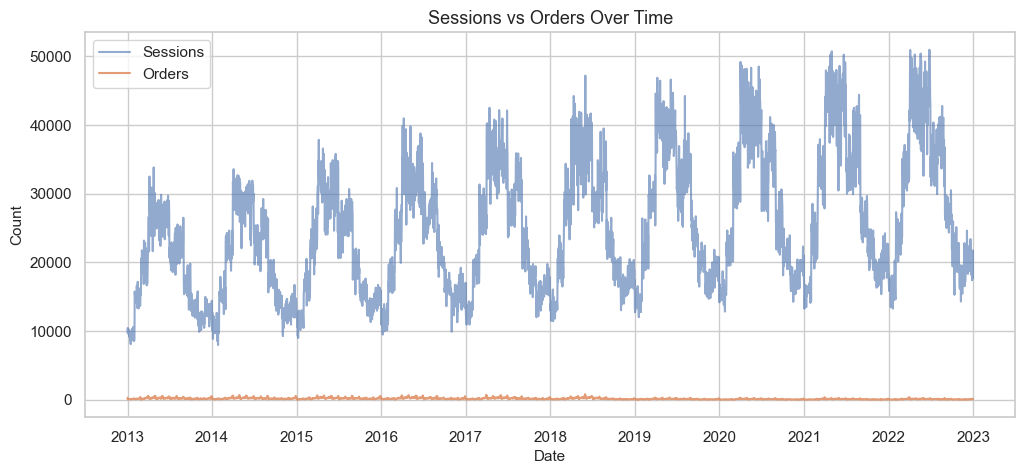

count    3652.000000
mean        0.007356
std         0.005052
min         0.000390
25%         0.003465
50%         0.006315
75%         0.009539
max         0.043889
Name: orders_per_session, dtype: float64

In [17]:
traffic = web_traffic.copy()
traffic_daily = traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum')
)

daily_orders = daily_orders.rename(columns={'order_date': 'date'})
demand = traffic_daily.merge(daily_orders, on='date', how='left').fillna(0)
demand['orders_per_session'] = demand['orders'] / demand['sessions'].replace(0, np.nan)

fig, ax = plt.subplots()
ax.plot(demand['date'], demand['sessions'], label='Sessions', alpha=0.6)
ax.plot(demand['date'], demand['orders'], label='Orders', alpha=0.8)
ax.set_title('Sessions vs Orders Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.show()

demand['orders_per_session'].describe()

**Insights**
- Orders per session average **0.74%**, with a median around **0.63%** and a 95th percentile near **1.73%**.
- This is only a coarse conversion proxy because traffic logs and order events may not represent the exact same funnel step, but it still suggests that traffic spikes do not automatically translate into strong commercial efficiency.

**Business implication**
- Use high-traffic windows to test landing-page relevance and channel targeting, but do not treat traffic alone as the main lever for profitability.


## 7) Inventory is the operational bottleneck, not shipping
Inventory matters because it directly limits revenue capture. The key question is where stockout exposure overlaps with the categories that matter most economically.


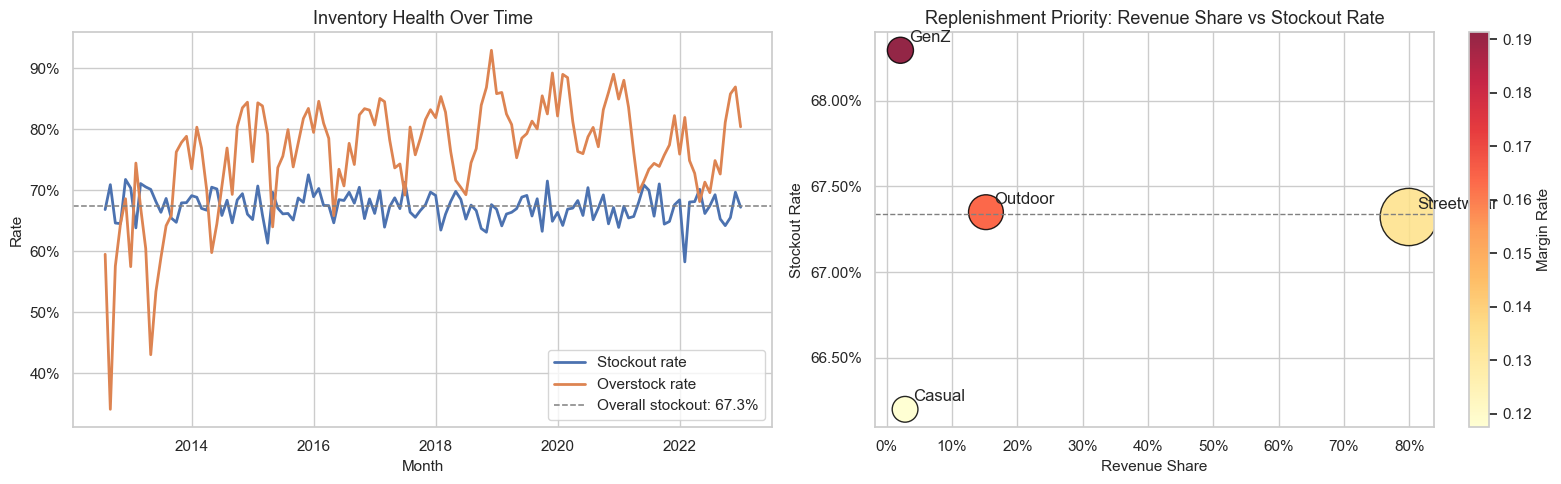

,category,stockout_rate,sell_through,revenue,gross_profit,margin_rate,revenue_share
3,Streetwear,0.673211,0.159754,1.313135e+10,1.738677e+09,0.132407,0.799207
2,Outdoor,0.673492,0.135084,2.494883e+09,4.085200e+08,0.163743,0.151845
0,Casual,0.662004,0.168390,4.606484e+08,5.410395e+07,0.117452,0.028036
1,GenZ,0.682927,0.167978,3.435991e+08,6.572530e+07,0.191285,0.020912


In [18]:
inv_monthly = inventory.groupby('snapshot_date', as_index=False).agg(
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    sell_through=('sell_through_rate', 'mean')
)

overall_stockout_rate = inventory['stockout_flag'].mean()

stockout_by_category = inventory.groupby('category', as_index=False).agg(
    stockout_rate=('stockout_flag', 'mean'),
    sell_through=('sell_through_rate', 'mean')
)
inventory_priority = stockout_by_category.merge(
    mix[['category', 'revenue', 'gross_profit', 'margin_rate', 'revenue_share']],
    on='category',
    how='left'
).sort_values('revenue_share', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['stockout_rate'], label='Stockout rate', linewidth=2.0)
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['overstock_rate'], label='Overstock rate', linewidth=2.0)
axes[0].axhline(overall_stockout_rate, color='gray', linestyle='--', linewidth=1.1,
                label=f"Overall stockout: {overall_stockout_rate:.1%}")
axes[0].set_title('Inventory Health Over Time')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Rate')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()

bubble_size = 300 + 1400 * (inventory_priority['gross_profit'] / inventory_priority['gross_profit'].max())
scatter = axes[1].scatter(inventory_priority['revenue_share'], inventory_priority['stockout_rate'],
                          s=bubble_size, c=inventory_priority['margin_rate'], cmap='YlOrRd',
                          alpha=0.85, edgecolor='black')
for _, row in inventory_priority.iterrows():
    axes[1].annotate(row['category'], (row['revenue_share'], row['stockout_rate']),
                     textcoords='offset points', xytext=(6, 6))
axes[1].axhline(overall_stockout_rate, color='gray', linestyle='--', linewidth=1.0)
axes[1].set_title('Replenishment Priority: Revenue Share vs Stockout Rate')
axes[1].set_xlabel('Revenue Share')
axes[1].set_ylabel('Stockout Rate')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.colorbar(scatter, ax=axes[1], label='Margin Rate')

plt.tight_layout()
plt.show()

display(inventory_priority)


**Insights**
- Overall stockout rate is **67.34%**, measured here as a **product-month average**, which is extremely high for a business that is still trying to grow profitably.
- **Streetwear** carries both the largest revenue share (**79.9%**) and a stockout rate near the portfolio average (**67.3%**), so a large share of potential lost sales is likely concentrated in the core category.
- **GenZ** has the highest stockout rate (**68.3%**) and the highest margin rate (**19.1%**), but its revenue base is small. That makes it a selective replenishment opportunity, not the first place to scale.

**Business implication**
- Rank replenishment by a three-part rule: high revenue share, high stockout rate, and acceptable margin. In practice, protecting Streetwear availability should dominate the queue: even a modest **5 percentage-point** reduction in Streetwear stockout would matter more commercially than optimizing a much smaller category first.


## 8) Final takeaways
1. **Margin leakage is the core issue.** Revenue reconstruction is clean, and **100%** of the top `0.5%` `COGS / Revenue` spike days fall inside Urban Blowout windows where `COGS / Revenue` rises to roughly `1.44x-1.57x`.
2. **Traffic growth is not the same as commercial quality.** The 2020-2021 structural-break lens shows higher sessions but weaker conversion, lower revenue, and softer margin, while promo intensity rises.
3. **Promotions and category mix need stricter economic control.** Promo orders carry `20.5%` lower AOV, Streetwear drives almost `80%` of revenue with weaker margin efficiency, and month-1 retention remains only `3.55%`.
4. **Inventory is the main operational bottleneck.** Product-month stockout is `67.34%` overall, so demand or traffic forecasts that ignore availability will overstate realizable revenue.

**Prescriptive next steps**
- Add campaign guardrails with a minimum projected gross-margin floor such as `10%-15%`, and hard-block any launch with projected `COGS / Revenue >= 1.0x`.
- Rebuild promo mechanics around minimum basket size and category-specific discount caps.
- Protect Streetwear availability first, then restock GenZ and Outdoor selectively for margin lift.
- Trigger lifecycle campaigns within 30-60 days after first purchase to improve repeat rate.
- Treat 2020-2021 as a structural-break checkpoint when planning, rather than extrapolating traffic or top-line growth in isolation.

Appendix sections on returns, shipping, ratings, and web traffic remain useful for monitoring, but they do not appear to be the main levers for this dataset.
